#---EXPERIMENTAL--- (8 Maret 2025)

##Importing Data

In [ ]:
from google.colab import files
import numpy as np
import pandas as pd
from scipy import signal
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, hilbert,lfilter, savgol_filter
from scipy.signal import find_peaks, peak_widths, chirp, argrelextrema, welch
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


20.0
(20, 16384)
(20, 16384)


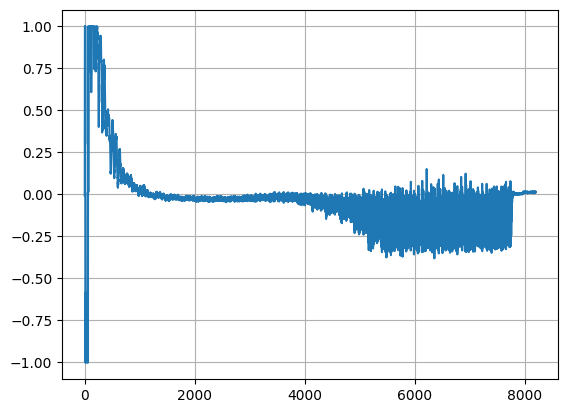

In [ ]:
import os
import numpy as np
# Folder
folder_path = '/content/drive/MyDrive/Colab Notebooks/New Ultrasound Signal/1. Tepi'
# Include semua file npz
npz_files = [f for f in os.listdir(folder_path) if f.endswith('.npz')]
# Load
data_list = []
for file_name in npz_files:
    file_path = os.path.join(folder_path, file_name)
    data = np.load(file_path)
    data_list.append(data)
# time dan signal data
data_time = []
data_signal = []
for i in range(len(data_list)):
  data_time.append(data_list[i]['t'])
  data_signal.append(data_list[i]['signal'][0].T.flatten())
data_len = 0
for i in range(len(data_list)):
  data_len = (data_len + len(data_list[i]))
  data_length = data_len / 15
print(data_length)
print(np.shape(data_time))
print(np.shape(data_signal))
# Visualisasi Data
plt.plot(data_time[1], data_signal[19])
plt.grid(True)

##Bandpass

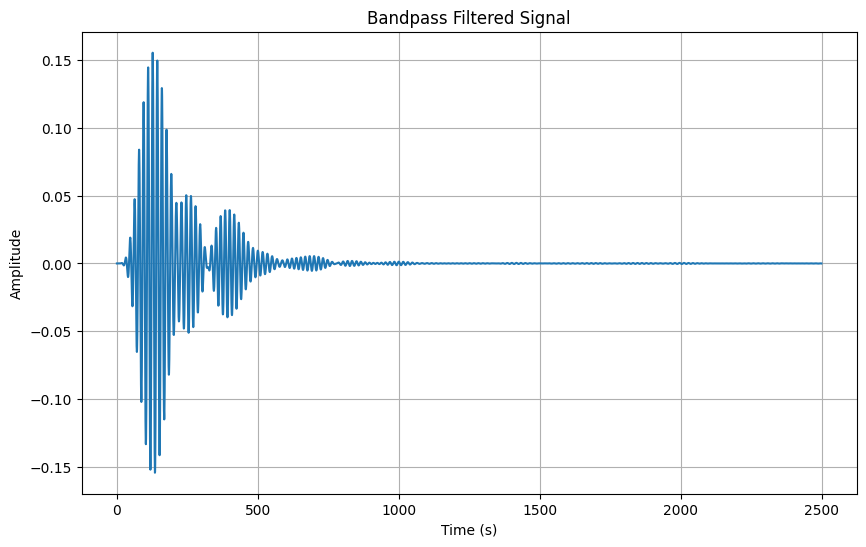

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter

# Data trimming and Damping
damped_signal = []
time = []
for i in range(len(data_signal)):
    current_time = data_time[i][:5000]
    current_signal = data_signal[i][:5000]
    damped_signal.append(-current_signal)
    time.append(current_time)

time = time[1]  # Using time from second file
order1 = 5

# Bandpass Filter Setup
def butter_bandpass(lowcut, highcut, fs, order=order1):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return b, a

def apply_bandpass_filter(signal, lowcut, highcut, fs, order=order1):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = lfilter(b, a, signal)
    return y

# Apply bandpass
bandpass_signal = []
for signal in damped_signal:
    filtered = apply_bandpass_filter(signal, 0.48e6, 0.52e6, 8e6)
    bandpass_signal.append(filtered)

# Plotting
plt.figure(figsize=(10,6))
plt.plot(time, bandpass_signal[19])
plt.title(f"Bandpass Filtered Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

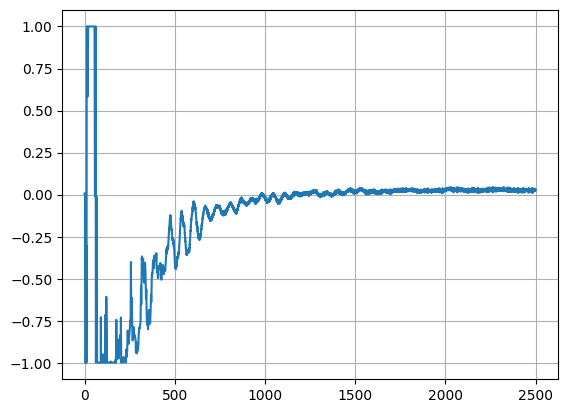

In [ ]:
plt.plot(time, damped_signal[19])
plt.grid(True)

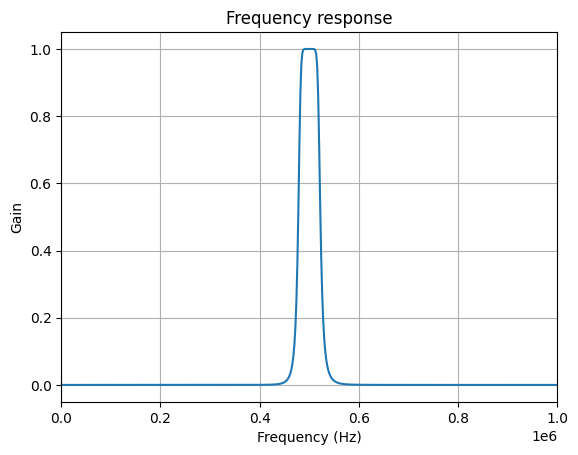

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, freqz

def butter_bandpass(lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

fs = 8e6
lowcut = 0.48e6
highcut = 0.52e6
order = 5

b, a = butter_bandpass(lowcut, highcut, fs, order=order)

# Plot frequency response
w, h = freqz(b, a, worN=2000)
plt.plot((w / np.pi) * (fs/2), abs(h))
plt.title('Frequency response')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Gain')
plt.xlim(0,1e6)
plt.ylim()
plt.grid()
plt.show()


##Enveloping Process

In [ ]:
# Envelope
from scipy.signal import hilbert, chirp
from scipy.interpolate import interp1d
def get_envelope_v1(x, y):
    x_list, y_list = list(x), list(y)
    assert len(x_list) == len(y_list)

    # First data
    ui, ux, uy = [0], [x_list[0]], [y_list[0]]
    li, lx, ly = [0], [x_list[0]], [y_list[0]]

    # Find upper peaks and lower peaks
    for i in range(1, len(x_list)-1):
        if y_list[i] >= y_list[i-1] and y_list[i] >= y_list[i+1]:
            ui.append(i)
            ux.append(x_list[i])
            uy.append(y_list[i])
        if y_list[i] <= y_list[i-1] and y_list[i] <= y_list[i+1]:
            li.append(i)
            lx.append(x_list[i])
            ly.append(y_list[i])

    # Last data
    ui.append(len(x_list)-1)
    ux.append(x_list[-1])
    uy.append(y_list[-1])
    li.append(len(y_list)-1)
    lx.append(x_list[-1])
    ly.append(y_list[-1])

    if len(ux) == 2 or len(lx) == 2:
        return [], []

    else:
        func_ub = interp1d(ux, uy, kind='cubic', bounds_error=False)
        func_lb = interp1d(lx, ly, kind='cubic', bounds_error=False)

        ub, lb = [], []
        for i in x_list:
            ub = func_ub(x_list)
            lb = func_lb(x_list)

        ub = np.array([y, ub]).max(axis=0)
        lb = np.array([y, lb]).min(axis=0)

        return ub, lb

time
rectification_signal = []
enveloped_signal = []
#nd_enveloped_signal = []
for i in bandpass_signal:
  rectification_signal.append(np.abs(i))
for j in rectification_signal:
  envelope, ly = get_envelope_v1(time, j)
  enveloped_signal.append(envelope)

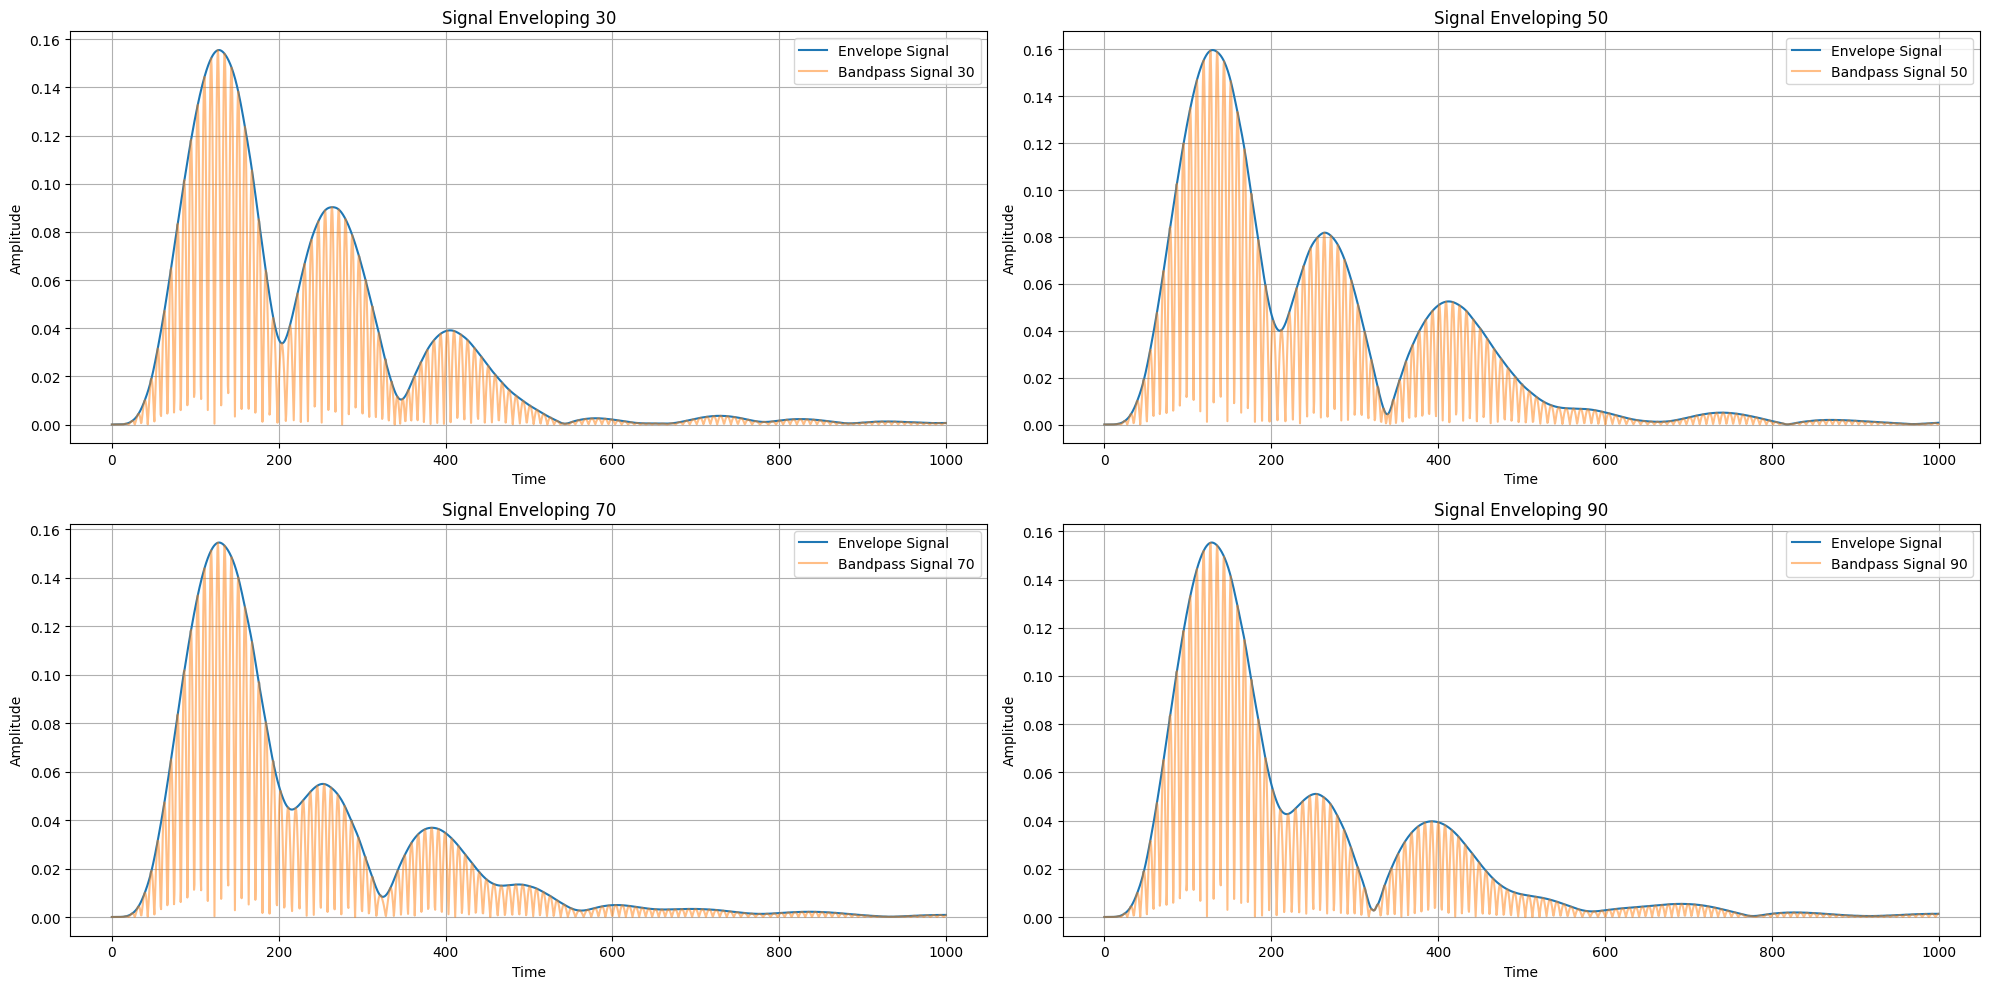

In [ ]:
plt.figure(figsize=(20,10))
plt.subplot(2,2,1)
plt.title('Signal Enveloping 30')
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.plot (time[:2000], enveloped_signal[4][:2000], label = 'Envelope Signal')
plt.plot (time[:2000], np.abs(rectification_signal[4][:2000]), label = 'Bandpass Signal 30', alpha = 0.5)
plt.grid(True)
plt.tight_layout()
plt.legend()

plt.subplot(2,2,2)
plt.title('Signal Enveloping 50')
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.plot (time[:2000], enveloped_signal[9][:2000], label = 'Envelope Signal')
plt.plot (time[:2000], np.abs(rectification_signal[9][:2000]), label = 'Bandpass Signal 50', alpha = 0.5)
plt.grid(True)
plt.tight_layout()
plt.legend()

plt.subplot(2,2,3)
plt.title('Signal Enveloping 70')
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.plot (time[:2000], enveloped_signal[14][:2000], label = 'Envelope Signal')
plt.plot (time[:2000], np.abs(rectification_signal[14][:2000]), label = 'Bandpass Signal 70', alpha = 0.5)
plt.grid(True)
plt.tight_layout()
plt.legend()

plt.subplot(2,2,4)
plt.title('Signal Enveloping 90')
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.plot (time[:2000], enveloped_signal[19][:2000], label = 'Envelope Signal')
plt.plot (time[:2000], np.abs(rectification_signal[19][:2000]), label = 'Bandpass Signal 90', alpha = 0.5)
plt.grid(True)
plt.tight_layout()
plt.legend()

plt.show()

##Manual Feature Extraction

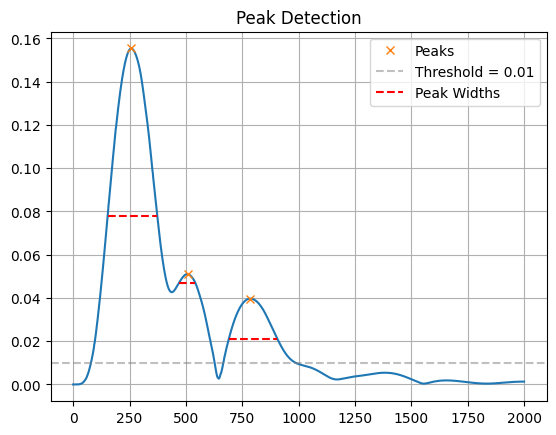

,Peak Position,Peak Amplitude,Peak Width
0,258,0.155352,220.661555
1,507,0.051069,73.534936
2,785,0.039695,214.335511


In [ ]:
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

#Signal Peak Parameter
selected_index = 19
threshold = 0.01

#Block Parameter
d = 7.5e-2

peaks, _ = find_peaks(enveloped_signal[selected_index], height = threshold)
widths, width_heights, left_ips, right_ips = peak_widths(enveloped_signal[selected_index], peaks, rel_height=0.5)

plt.title(f"Peak Detection")
plt.plot(enveloped_signal[selected_index][:2000])
plt.plot(peaks, enveloped_signal[selected_index][peaks][:2000], "x", label = "Peaks")
plt.axhline(y=threshold, color='gray', linestyle='--', label = f"Threshold = {threshold}", alpha=0.5)
plt.hlines(width_heights, left_ips, right_ips, color="red", linestyle="--", label="Peak Widths")
plt.legend()
plt.grid(True)
plt.show()

#Peak Analysis Dataframe
peak_df = pd.DataFrame(peaks)
peak_amp_df = pd.DataFrame(enveloped_signal[selected_index][peaks])
peak_width_df = pd.DataFrame(widths)
peak_detect_df = pd.concat([peak_df, peak_amp_df, peak_width_df], axis = 1).set_axis(['Peak Position', 'Peak Amplitude', 'Peak Width'], axis = 1)
peak_detect_df

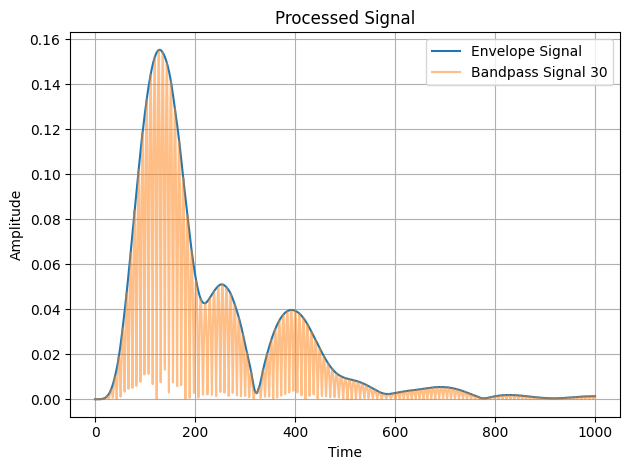

In [ ]:
plt.title('Processed Signal')
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.plot (time[:2000], enveloped_signal[19][:2000], label = 'Envelope Signal')
plt.plot (time[:2000], np.abs(rectification_signal[19][:2000]), label = 'Bandpass Signal 30', alpha = 0.5)
plt.grid(True)
plt.tight_layout()
plt.legend()

In [ ]:
#Peak Parameter
max_peak_index = 0
min_peak_index = 2

from scipy.fft import fft, fftfreq
from scipy.stats import skew, kurtosis
#Skewness and Kurtosis
envelope_signal = enveloped_signal[selected_index]
window_size = 100  # adjust as needed
skewness_values = []
kurtosis_values = []

for start in range(0, len(envelope_signal) - window_size, window_size):
    window = envelope_signal[start:start + window_size]
    skewness_values.append(skew(window))
    kurtosis_values.append(kurtosis(window, fisher=True))

#Number of Peaks
num_of_peaks = peak_detect_df.shape[0]

#Max Amplitude
pulse_max_amplitude = peak_detect_df[['Peak Amplitude']].max().values

#Peak Width
pulse_max_peak_width = peak_detect_df[['Peak Width']].max().values

#Time to Peak
sample_rate=8e6
max_amp_idx = peak_detect_df['Peak Amplitude'].idxmax()
time_to_peak_raw = peak_detect_df['Peak Position'].loc[max_amp_idx]
time_to_peak = time_to_peak_raw/20

#Velocity
max_amp_pos = peak_detect_df['Peak Position'][max_peak_index]
min_amp_pos = peak_detect_df['Peak Position'][min_peak_index]
velocity = d / (((np.abs(max_amp_pos - min_amp_pos))/20*1e-6))

#Attenuation
max_amp = peak_detect_df['Peak Amplitude'][max_peak_index]
min_amp = peak_detect_df['Peak Amplitude'][min_peak_index]
attenuation = np.round((-(np.log10((max_amp/min_amp)/2.8e-2))), 2) if min_amp != 0 else float('inf')

skew_value = []
kurtosis_value = []

#Skew
skewness_values_np = np.array(skewness_values)
normal_skewness_values = (skewness_values_np>(-5e-1)) & (skewness_values_np<(5e-1))
filtered_skewness_value = skewness_values_np[normal_skewness_values]
skew_mean = np.mean(filtered_skewness_value)
skew_value.append(skew_mean)

#Kurtosis
kurtosis_values_np = np.array(kurtosis_values)
normal_kurtosis_values = (kurtosis_values_np>(-5e-1)) & (kurtosis_values_np<(5e-1))
filtered_kurtosis_value = kurtosis_values_np[normal_kurtosis_values]
kurtosis_mean = np.mean(filtered_kurtosis_value)
kurtosis_value.append(kurtosis_mean)

#Spectral Centroid Bandpass
def calculate_spectral_centroid_bandpass(signal, sample_rate):
    n = len(signal)

    # Compute FFT and take absolute value
    fft_result = fft(signal)
    magnitudes_bandpass = np.abs(fft_result)[:n//2]  # Take only positive frequencies
    magnitudes_bandpass = magnitudes_bandpass / np.max(magnitudes_bandpass)  # Normalize

    # Calculate frequencies
    frequencies_bandpass = fftfreq(n, 1/sample_rate)[:n//2]

    # Calculate spectral centroid
    if np.sum(magnitudes_bandpass) > 0:
        centroid_bandpass = np.sum(frequencies_bandpass * magnitudes_bandpass) / np.sum(magnitudes_bandpass)
    else:
        centroid = 0

    return centroid_bandpass, frequencies_bandpass, magnitudes_bandpass

centroid_bandpass, frequencies_bandpass, magnitudes_bandpass = calculate_spectral_centroid_bandpass(bandpass_signal[selected_index], 8e6)

#Spectral Centroid Envelope
def calculate_spectral_centroid_envelope(signal, sample_rate):
    n = len(signal)

    # Compute FFT and take absolute value
    fft_result = fft(signal)
    magnitudes_envelope = np.abs(fft_result)[:n//2]  # Take only positive frequencies
    magnitudes_envelope = magnitudes_envelope / np.max(magnitudes_envelope)  # Normalize

    # Calculate frequencies
    frequencies_envelope = fftfreq(n, 1/sample_rate)[:n//2]

    # Calculate spectral centroid
    if np.sum(magnitudes_envelope) > 0:
        centroid_envelope = np.sum(frequencies_envelope * magnitudes_envelope) / np.sum(magnitudes_envelope)
    else:
        centroid = 0

    return centroid_envelope, frequencies_envelope, magnitudes_envelope

centroid_envelope, frequencies_envelope, magnitudes_envelope = calculate_spectral_centroid_bandpass(enveloped_signal[selected_index], 8e6)

#Entropy
from scipy.stats import entropy
hist, _ = np.histogram(bandpass_signal[selected_index], bins=min(50, len(np.unique(bandpass_signal[selected_index]))), density=True)
signal_entropy = entropy(hist) if np.sum(hist) > 0 else 0
signal_entropy

print(f"Signal ID: {selected_index}\n"
      f"Number of Peak: {num_of_peaks}\n"
      f"Pulse (Max) Peak Amp: {pulse_max_amplitude}\n"
      f"Pulse (Max) Peak Width: {pulse_max_peak_width}\n"
      f"Time2Peak: {time_to_peak}\n"
      f"Velocity: {velocity}\n"
      f"Attenuation: {attenuation}\n"
      f"Skewness: {skew_value}\n"
      f"Kurtosis: {kurtosis_value}\n"
      f"Centroid Bandpass: {centroid_bandpass}\n"
      f"Centroid Envelope: {centroid_envelope}\n"
      f"Entropy: {signal_entropy}\n")

# Excel Input
metrics = {
    "Number of Peak": num_of_peaks,
    "Pulse (Max) Peak Amp": pulse_max_amplitude[0],
    "Pulse (Max) Peak Width": pulse_max_peak_width[0],
    "Time2Peak": time_to_peak,
    "Velocity": velocity,
    "Attenuation": attenuation,
    "Skewness": skew_value[0],
    "Kurtosis": kurtosis_value[0],
    "Centroid Bandpass": centroid_bandpass,
    "Centroid Envelope": centroid_envelope,
    "Entropy": signal_entropy
}

import pandas as pd
'''
# Print tab-separated headers + values (Excel-friendly)
print("\t".join(metrics.keys()))  # Column headers
print("\t".join(map(str, metrics.values())))  # Values
'''
print(",".join(metrics.keys()))  # Column headers
print(",".join(map(str, metrics.values())))  # Values

Signal ID: 19
Number of Peak: 3
Pulse (Max) Peak Amp: [0.15535162]
Pulse (Max) Peak Width: [220.66155519]
Time2Peak: 12.9
Velocity: 2846.299810246679
Attenuation: -2.15
Skewness: [np.float64(-0.08681117322630003)]
Kurtosis: [np.float64(-0.10384231427822532)]
Centroid Bandpass: 246912.82477243376
Centroid Envelope: 26744.306174499274
Entropy: 1.2775321490624538

Number of Peak,Pulse (Max) Peak Amp,Pulse (Max) Peak Width,Time2Peak,Velocity,Attenuation,Skewness,Kurtosis,Centroid Bandpass,Centroid Envelope,Entropy
3,0.15535161558856508,220.66155518980005,12.9,2846.299810246679,-2.15,-0.08681117322630003,-0.10384231427822532,246912.82477243376,26744.306174499274,1.2775321490624538


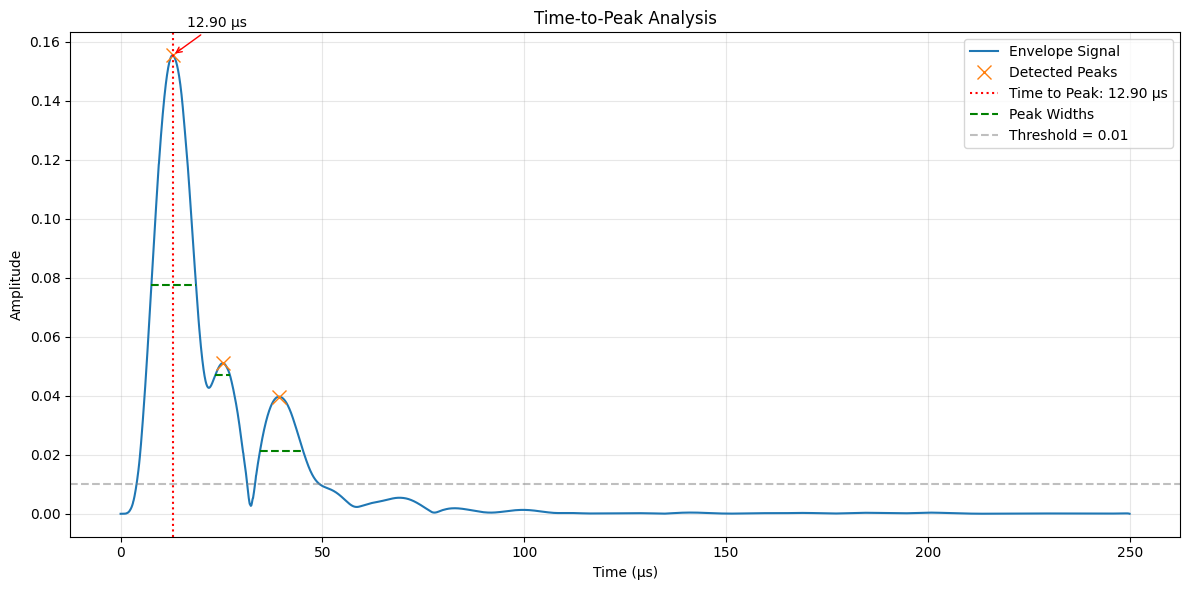

Time to peak: 12.90 microseconds


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks, peak_widths

def visualize_time_to_peak(signal, selected_index, threshold, sample_rate=8e6):
    # Find peaks
    peaks, _ = find_peaks(signal[selected_index], height=threshold)
    widths, width_heights, left_ips, right_ips = peak_widths(signal[selected_index], peaks, rel_height=0.5)

    # Convert positions to time (microseconds)
    '''
    max_amp_idx = peak_detect_df['Peak Amplitude'].idxmax()
    time_to_peak_raw = peak_detect_df['Peak Position'].loc[max_amp_idx]
    time = time_to_peak_raw/20 #in Microsecond
    sample_rate * 1e6
    '''
    time = np.arange(len(signal[selected_index])) / 20  # μs

    # Create figure
    plt.figure(figsize=(12, 6))

    # Plot signal and peaks
    plt.plot(time, signal[selected_index], label='Envelope Signal')
    plt.plot(time[peaks], signal[selected_index][peaks], "x", markersize=10, label='Detected Peaks')

    # Highlight time to max peak
    max_peak_idx = np.argmax(signal[selected_index][peaks])
    time_to_peak = time[peaks][max_peak_idx]

    # Annotate time to peak
    plt.axvline(x=time_to_peak, color='red', linestyle=':',
                label=f'Time to Peak: {time_to_peak:.2f} μs')
    plt.annotate(f'{time_to_peak:.2f} μs',
                 xy=(time_to_peak, signal[selected_index][peaks][max_peak_idx]),
                 xytext=(10, 20), textcoords='offset points',
                 arrowprops=dict(arrowstyle="->", color='red'))

    # Add peak width markers
    plt.hlines(width_heights,
               time[np.floor(left_ips).astype(int)],
               time[np.floor(right_ips).astype(int)],
               color="green", linestyle="--", label="Peak Widths")

    # Threshold line
    plt.axhline(y=threshold, color='gray', linestyle='--', alpha=0.5, label=f'Threshold = {threshold}')

    # Formatting
    plt.title(f"Time-to-Peak Analysis")
    plt.xlabel("Time (μs)")
    plt.ylabel("Amplitude")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return time_to_peak

# Example usage
time_to_peak = visualize_time_to_peak(enveloped_signal, selected_index, threshold)
print(f"Time to peak: {time_to_peak:.2f} microseconds")

In [ ]:
#PSD and FFT
fft_signal = []
freq_fft = []
freqacq = 8*10**6
for i in bandpass_signal:
  fft_signal.append(np.fft.fft(i))
  freq_fft.append(np.fft.fftfreq(len(i), d=1/freqacq))
abs_fft = np.abs(fft_signal)
abs_freqspace = np.abs(freq_fft)

psd_signal = []
for i in bandpass_signal:
  freq, psd = welch(i, freqacq, nperseg=1024)
  psd_signal.append(psd)

magnitude = []
integer = []
max_value_psd =[]
max_value_fft =[]
max_value_fft_imag = []

for i in range(len(psd_signal)):
  if i>0:
    rounded_psd = np.round(psd_signal[i], decimals = 10)
    max_value_psd.append(max(rounded_psd)*10**8)
  else:
    continue
for j in range(len(fft_signal)):
  if i>0:
    magnitude = np.abs(fft_signal[j])
    integer_magnitude = np.round(magnitude).astype(int)
    max_value_fft.append(max(integer_magnitude))
  else:
    continue

data_max_value_psd = pd.DataFrame(max_value_psd, columns = ["PSD"])
data_max_value_fft = pd.DataFrame(max_value_fft, columns = ["FFT"])

frequency_data = pd.concat([data_max_value_psd, data_max_value_fft], axis=1)
frequency_data = frequency_data.fillna(frequency_data['PSD'][45:60].median())

frequency_data

,PSD,FFT
0,1.58,23
1,1.63,22
2,1.67,22
3,1.75,22
4,1.71,23
5,1.68,22
6,1.94,22
7,1.71,25
8,2.00,22
9,1.76,26


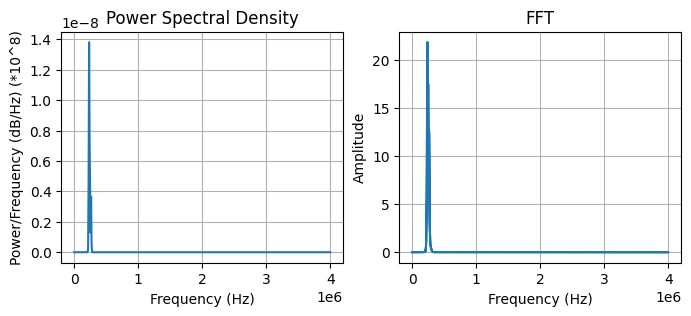

In [ ]:
plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.plot(freq, psd_signal[19])
plt.title("Power Spectral Density")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power/Frequency (dB/Hz) (*10^8)")
plt.grid(True)
plt.subplot(1,2,2)
plt.plot(abs_freqspace[19], abs_fft[19])
plt.title("FFT")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.grid(True)

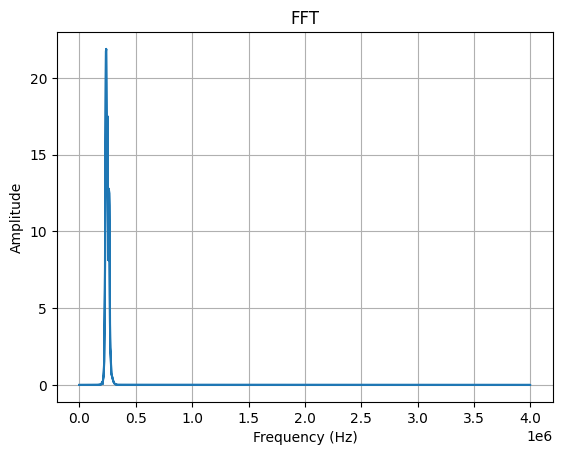

In [ ]:
plt.plot(abs_freqspace[19], abs_fft[19])
plt.title("FFT")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.grid(True)

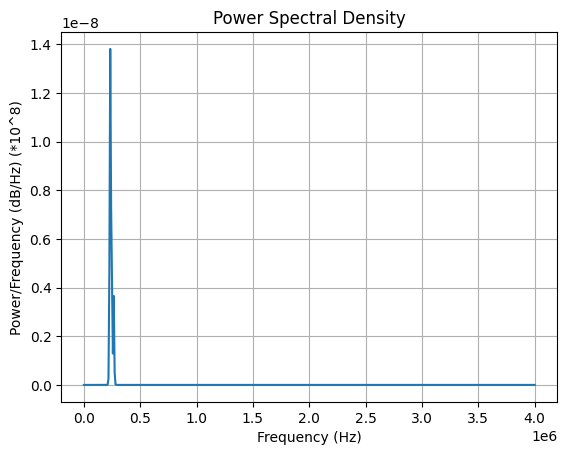

In [ ]:
plt.plot(freq, psd_signal[19])
plt.title("Power Spectral Density")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power/Frequency (dB/Hz) (*10^8)")
plt.grid(True)

246912.82477243376


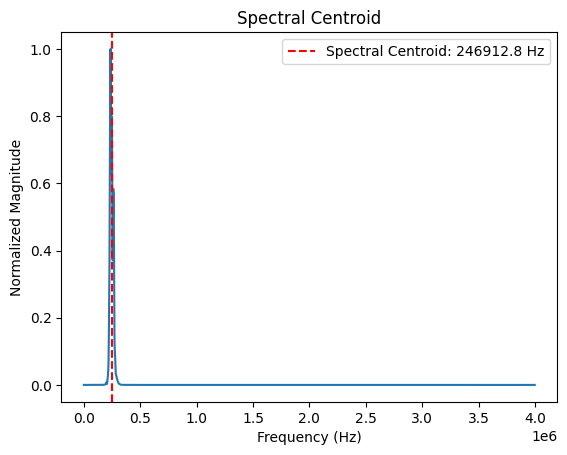

In [ ]:
plt.plot(frequencies_bandpass, magnitudes_bandpass)
plt.axvline(centroid_bandpass, color='r', linestyle='--', label=f'Spectral Centroid: {centroid_bandpass:.1f} Hz')
plt.title("Spectral Centroid")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Magnitude")
plt.legend()

print(centroid_bandpass)

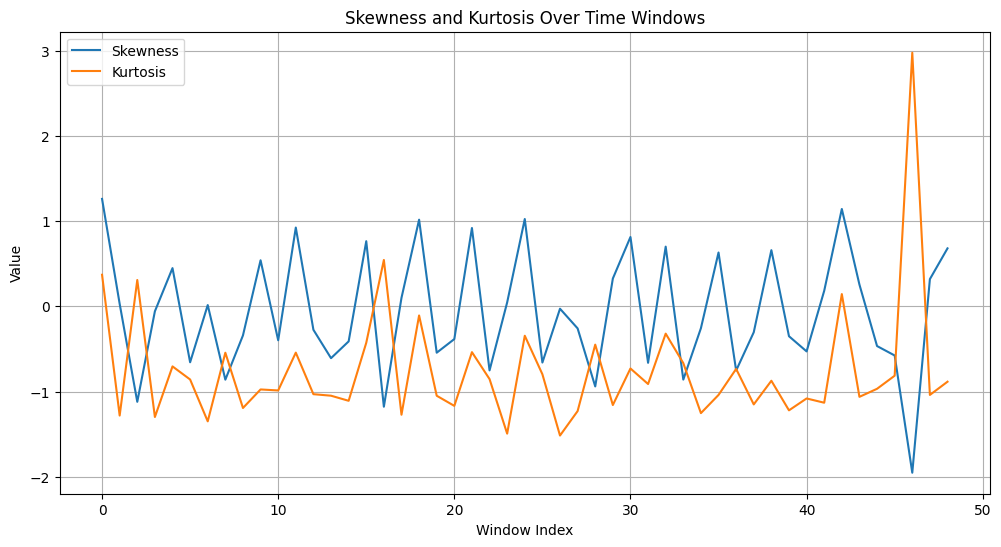

In [ ]:
# Plot skewness and kurtosis over time windows
plt.figure(figsize=(12, 6))
plt.plot(skewness_values, label='Skewness')
plt.plot(kurtosis_values, label='Kurtosis')
plt.title('Skewness and Kurtosis Over Time Windows')
plt.xlabel('Window Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

Dominant frequency of the signal: 0.23679999999999998 MHz


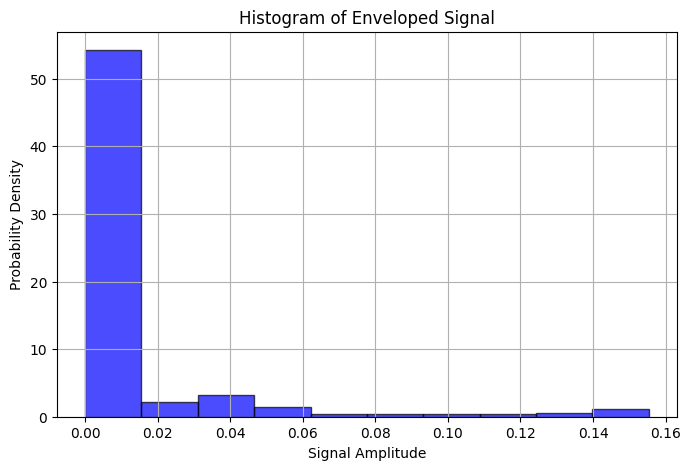

In [ ]:
import numpy as np
import pandas as pd

# Assuming bandpass_signal[selected_index] is your signal array
fft_result = np.fft.fft(bandpass_signal[selected_index])
fft_magnitude = np.abs(fft_result)

T = 1 / 8e6  # Sampling interval (from your code)
freqs = np.fft.fftfreq(len(bandpass_signal[selected_index]), T)

# Select only positive frequencies
positive_freqs = freqs[freqs >= 0]
positive_magnitude = fft_magnitude[freqs >= 0]

# Find index of peak magnitude
peak_index = np.argmax(positive_magnitude)

# Find the dominant frequency
dominant_frequency = positive_freqs[peak_index]

print(f"Dominant frequency of the signal: {dominant_frequency*1e-6} MHz") #Based on the Transducer used

#Data Distribution
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Your signal data
data = enveloped_signal[selected_index]

# Number of bins (as you used)
num_bins = min(10, len(np.unique(data)))

plt.figure(figsize=(8, 5))
plt.hist(data, bins=num_bins, density=True, alpha=0.7, color='blue', edgecolor='black')
plt.title('Histogram of Enveloped Signal')
plt.xlabel('Signal Amplitude')
plt.ylabel('Probability Density')
plt.grid(True)
plt.show()

Dominant frequency: 0.23679999999999998 MHz
Skewness: 3.51


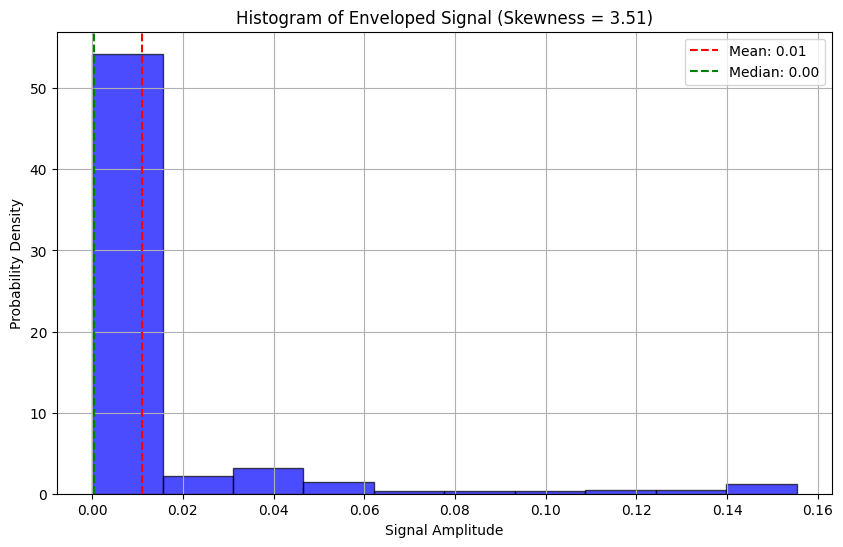

The distribution is RIGHT-SKEWED (tail extends to the right).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew

# --- Your existing FFT analysis (unchanged) ---
fft_result = np.fft.fft(bandpass_signal[selected_index])
fft_magnitude = np.abs(fft_result)
T = 1 / 8e6  # Sampling interval
freqs = np.fft.fftfreq(len(bandpass_signal[selected_index]), T)
positive_freqs = freqs[freqs >= 0]
positive_magnitude = fft_magnitude[freqs >= 0]
peak_index = np.argmax(positive_magnitude)
dominant_frequency = positive_freqs[peak_index]
print(f"Dominant frequency: {dominant_frequency*1e-6} MHz")

# --- Skewness Analysis ---
data = enveloped_signal[selected_index]
num_bins = min(10, len(np.unique(data)))

# Calculate skewness
skewness = skew(data)
print(f"Skewness: {skewness:.2f}")

# Plot histogram with skewness annotation
plt.figure(figsize=(10, 6))
plt.hist(data, bins=num_bins, density=True, alpha=0.7, color='blue', edgecolor='black')

# Add mean/median lines and skewness label
plt.axvline(np.mean(data), color='red', linestyle='dashed', linewidth=1.5, label=f'Mean: {np.mean(data):.2f}')
plt.axvline(np.median(data), color='green', linestyle='dashed', linewidth=1.5, label=f'Median: {np.median(data):.2f}')
plt.title(f'Histogram of Enveloped Signal (Skewness = {skewness:.2f})')
plt.xlabel('Signal Amplitude')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.show()

# Interpret skewness
if skewness > 0:
    print("The distribution is RIGHT-SKEWED (tail extends to the right).")
elif skewness < 0:
    print("The distribution is LEFT-SKEWED (tail extends to the left).")
else:
    print("The distribution is SYMMETRIC (no skew).")

Dominant frequency: 0.23679999999999998 MHz
Kurtosis: 15.48


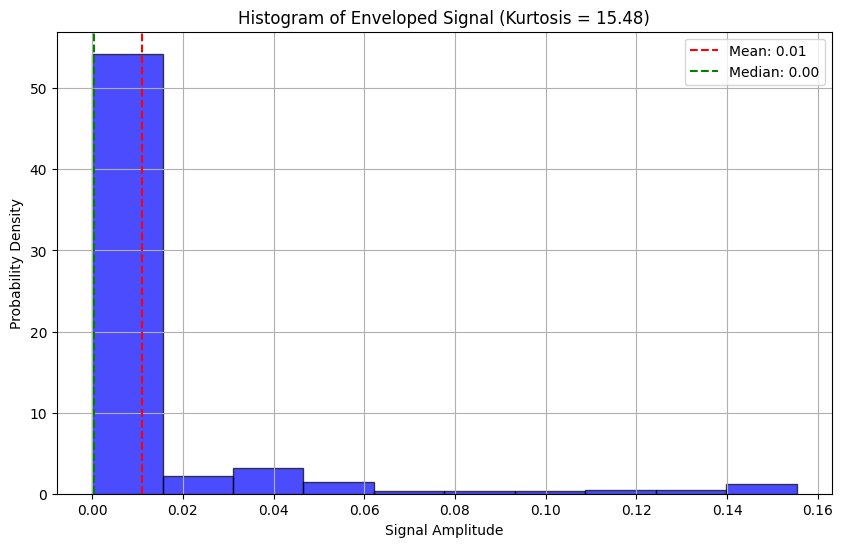

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kurtosis

# --- FFT Analysis (unchanged) ---
fft_result = np.fft.fft(bandpass_signal[selected_index])
fft_magnitude = np.abs(fft_result)
T = 1 / 8e6  # Sampling interval
freqs = np.fft.fftfreq(len(bandpass_signal[selected_index]), T)
positive_freqs = freqs[freqs >= 0]
positive_magnitude = fft_magnitude[freqs >= 0]
peak_index = np.argmax(positive_magnitude)
dominant_frequency = positive_freqs[peak_index]
print(f"Dominant frequency: {dominant_frequency*1e-6} MHz")

# --- Histogram + Kurtosis ---
data = enveloped_signal[selected_index]
num_bins = min(10, len(np.unique(data)))

# Calculate kurtosis
kurt = kurtosis(data, fisher=False)  # Fisher=False gives Pearson's definition (normal=3)
print(f"Kurtosis: {kurt:.2f}")

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(data, bins=num_bins, density=True, alpha=0.7, color='blue', edgecolor='black')

# Add kurtosis annotation
plt.axvline(np.mean(data), color='red', linestyle='dashed', linewidth=1.5, label=f'Mean: {np.mean(data):.2f}')
plt.axvline(np.median(data), color='green', linestyle='dashed', linewidth=1.5, label=f'Median: {np.median(data):.2f}')
plt.title(f'Histogram of Enveloped Signal (Kurtosis = {kurt:.2f})')
plt.xlabel('Signal Amplitude')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.show()

##Auto Feature Extraction

In [ ]:
import os
import numpy as np

# Directory where you want to save the processed .npz files
env_output_folder = '/content/drive/MyDrive/Colab Notebooks/Ultrasound Signal/New_Envelope_Transit2'

# Ensure the output directory exists
os.makedirs(env_output_folder, exist_ok=True)

# Assuming enveloped_signal is a list of arrays
for index, signal in enumerate(enveloped_signal):
    # Check the shape of the signal before saving
    #print(f"Signal {index} shape before saving: {signal.shape}")

    # Define the file name for each signal
    file_name = f'enveloped_signal_{index}.npz'
    file_path = os.path.join(env_output_folder, file_name)

    # Save each signal to an individual .npz file
    np.savez_compressed(file_path, enveloped_signal=signal)

#print(f"Processed files saved to {env_output_folder}")

# List all .npz files in the folder
env_npz_files = [f for f in os.listdir(env_output_folder) if f.endswith('.npz')]

# Load each .npz file
env_data_list = []
for env_file_name in env_npz_files:
    env_file_path = os.path.join(env_output_folder, env_file_name)
    env_data = np.load(env_file_path)

    # Access the array correctly
    signal = env_data['enveloped_signal']
    env_data_list.append(signal)

    # Check the shape of the loaded signal
    #print(f"Loaded signal shape from {env_file_name}: {signal.shape}")

In [ ]:
import numpy as np
import pandas as pd
from scipy.signal import find_peaks, peak_widths
from scipy.stats import skew, kurtosis, entropy
from scipy import fft
import pywt
from tabulate import tabulate
import os
import glob
from google.colab import drive

'''
to be eliminated:
time domain
1. signal_length (used but not extracted)
2. rise_time
3. fall_time
4. rise_fall_ratio
statistical
5. q1
6. q3
7. iqr
8. variance
9. rms
10. mean_abs
11. crest_factor
12. form_factor
13. impulse_factor
'''

def extract_features(envelope_signal, sample_id):
    """
    Extract features from an envelope signal and return them as a dictionary
    """
    # Amplitude-based features
    max_amplitude = np.max(envelope_signal)
    mean_amplitude = np.mean(envelope_signal)
    std_amplitude = np.std(envelope_signal)

    # Temporal features
    signal_length = len(envelope_signal)
    time_to_peak = np.argmax(envelope_signal)

    # Statistical features
    skewness_value = skew(envelope_signal)
    kurtosis_value = kurtosis(envelope_signal)

    # Peak-related features
    threshold = 0.125
    peaks, _ = find_peaks(envelope_signal, height = threshold)
    number_of_peaks = len(peaks)

    # Calculate prominence, peak distances only if peaks are found
    if number_of_peaks > 0:
        prominences = peak_widths(envelope_signal, peaks, rel_height=0.5)[1]  # Get prominences
        mean_prominence = np.mean(prominences) if len(prominences) > 0 else 0  # Calculate mean prominence

        peak_distances = np.diff(peaks)
        mean_peak_distance = np.mean(peak_distances) if len(peak_distances) > 0 else 0
        std_peak_distance = np.std(peak_distances) if len(peak_distances) > 0 else 0
    else:
        mean_prominence = 0  # or np.nan if you prefer to represent missing values
        mean_peak_distance = 0  # or np.nan
        std_peak_distance = 0  # or np.nan


    # Handle case when no peaks are found
    if number_of_peaks > 0:
        peak_widths_value = peak_widths(envelope_signal, peaks, rel_height=0.5)
        widths = peak_widths_value[0]
        mean_width = np.mean(widths) if len(widths) > 0 else 0

        # Attenuation calculation (if at least 2 peaks)
        if number_of_peaks >= 2:
            initial_amplitude = envelope_signal[peaks[0]]
            final_amplitude = envelope_signal[peaks[-1]]
            attenuation_db = 20 * np.log10(initial_amplitude / final_amplitude) if final_amplitude != 0 else float('inf')
        else:
            attenuation_db = np.nan
    else:
        mean_width = 0
        attenuation_db = np.nan

    # Energy-based features
    total_energy = np.sum(envelope_signal**2)

    # Shape-based features
    zero_crossing_rate = np.sum(np.diff(envelope_signal > 0))
    envelope_area = np.trapz(envelope_signal)

    # Frequency-domain features
    try:
        fft_values = np.abs(fft.fft(envelope_signal))
        fft_freq = fft.fftfreq(len(envelope_signal))

        # Skip DC component (index 0) for dominant frequency
        dominant_freq_idx = np.argmax(fft_values[1:]) + 1
        dominant_freq = abs(fft_freq[dominant_freq_idx])

        # Skip DC component for spectral calculations
        pos_indices = np.where(fft_freq > 0)[0]  # Use only positive frequencies
        if len(pos_indices) > 0:
            pos_fft_freq = fft_freq[pos_indices]
            pos_fft_values = fft_values[pos_indices]

            # Calculate spectral centroid and bandwidth if we have sufficient data
            if np.sum(pos_fft_values) > 0:
                spectral_centroid = np.sum(pos_fft_freq * pos_fft_values) / np.sum(pos_fft_values)
                spectral_bandwidth = np.sqrt(np.sum(((pos_fft_freq - spectral_centroid)**2) * pos_fft_values) / np.sum(pos_fft_values))
            else:
                spectral_centroid = 0
                spectral_bandwidth = 0

            # Spectral rolloff - frequency below which 85% of energy is contained
            spectral_rolloff = np.percentile(fft_values, 85)
        else:
            spectral_centroid = 0
            spectral_bandwidth = 0
            spectral_rolloff = 0
    except Exception as e:
        print(f"Error calculating frequency features for {sample_id}: {str(e)}")
        dominant_freq = 0
        spectral_centroid = 0
        spectral_bandwidth = 0
        spectral_rolloff = 0

    # Entropy-based features
    try:
        hist, _ = np.histogram(envelope_signal, bins=min(50, len(np.unique(envelope_signal))), density=True)
        signal_entropy = entropy(hist) if np.sum(hist) > 0 else 0
    except Exception as e:
        print(f"Error calculating entropy for {sample_id}: {str(e)}")
        signal_entropy = 0

    # Wavelet-based features
    try:
        # Use a smaller level if signal is short
        wavelet_level = min(3, int(np.log2(len(envelope_signal))) - 2)
        wavelet_level = max(1, wavelet_level)  # Ensure at least level 1

        coeffs = pywt.wavedec(envelope_signal, 'db4', level=wavelet_level)
        wavelet_energy = [np.sum(c**2) for c in coeffs]
        total_wavelet_energy = sum(wavelet_energy)
        wavelet_energy_ratio = wavelet_energy[0] / total_wavelet_energy if total_wavelet_energy > 0 else 0
    except Exception as e:
        print(f"Error calculating wavelet features for {sample_id}: {str(e)}")
        wavelet_energy_ratio = 0

    # Autocorrelation features
    try:
        autocorr = np.correlate(envelope_signal, envelope_signal, mode='full')
        autocorr = autocorr[len(autocorr)//2:]  # Use only the positive lags
        # Normalize
        autocorr = autocorr / np.max(autocorr) if np.max(autocorr) > 0 else autocorr

        # Find peaks in autocorrelation
        autocorr_peaks, _ = find_peaks(autocorr)
        first_autocorr_peak = autocorr_peaks[0] if len(autocorr_peaks) > 0 else 0
    except Exception as e:
        print(f"Error calculating autocorrelation for {sample_id}: {str(e)}")
        first_autocorr_peak = 0

    # Signal-to-noise ratio estimation (assuming first 10% is noise)
    noise_segment_size = max(1, int(signal_length * 0.1))  # Ensure at least 1 sample
    noise_level = np.std(envelope_signal[:noise_segment_size])
    signal_level = np.std(envelope_signal)
    snr = 20 * np.log10(signal_level / noise_level) if noise_level > 0 else np.nan

    # Return features as a dictionary
    return {
        'sample_id': sample_id,
        'max_amplitude': max_amplitude,
        'mean_amplitude': mean_amplitude,
        'std_amplitude': std_amplitude,
        'time_to_peak': time_to_peak,
        'skewness': skewness_value,
        'kurtosis': kurtosis_value,
        'number_of_peaks': number_of_peaks,
        'total_energy': total_energy,
        'zero_crossing_rate': zero_crossing_rate,
        'envelope_area': envelope_area,
        'mean_width': mean_width,
        'attenuation_db': attenuation_db,
        'dominant_freq': dominant_freq,
        'spectral_centroid': spectral_centroid,
        'spectral_bandwidth': spectral_bandwidth,
        'spectral_rolloff': spectral_rolloff,

        # Entropy features
        'signal_entropy': signal_entropy,

        # Wavelet features
        'wavelet_energy_ratio': wavelet_energy_ratio,

        # Peak features
        'mean_prominence': mean_prominence,
        'mean_peak_distance': mean_peak_distance,
        'std_peak_distance': std_peak_distance,

        # Autocorrelation
        'first_autocorr_peak': first_autocorr_peak,

        # SNR
        'snr_db': snr
    }

# Mount Google Drive
drive.mount('/content/drive')

# Path to directory containing your npz files in Google Drive
data_directory = '/content/drive/MyDrive/Colab Notebooks/Ultrasound Signal/New_Envelope_Transit2'

# Get all npz files in the directory
npz_files = glob.glob(os.path.join(data_directory, '*.npz'))

print(f"Found {len(npz_files)} .npz files in {data_directory}")

# Process all envelope signals
all_features = []
failed_files = []

for i, file_path in enumerate(npz_files):
    # Extract sample ID from filename
    file_name = os.path.basename(file_path)
    sample_id = os.path.splitext(file_name)[0]  # Remove extension

    try:
        # Load the npz file
        npz_data = np.load(file_path, allow_pickle=True)

        # Extract the envelope signal - may need to adjust based on your file structure
        # Option 1: If npz contains a single array without explicit keys
        if len(npz_data.files) == 1:
            envelope_signal = npz_data[npz_data.files[0]]
        # Option 2: If npz contains a key named 'envelope'
        elif 'envelope' in npz_data:
            envelope_signal = npz_data['envelope']
        # Option 3: For any other key structure - replace with your actual key
        else:
            # Print available keys for debugging
            print(f"Available keys in {file_name}: {npz_data.files}")
            # Try the first key as a fallback
            envelope_signal = npz_data[npz_data.files[0]]

        # Extract features
        features = extract_features(envelope_signal, sample_id)

        # Try to extract target value from filename, if applicable
        # Example: if filename format is "sample_X_target_Y.npz"
        # Uncomment and modify this block based on your filename format:

        all_features.append(features)

        # Progress indicator
        if (i+1) % 10 == 0 or (i+1) == len(npz_files):
            print(f"Processed {i+1} of {len(npz_files)} files")

    except Exception as e:
        print(f"Error processing file {file_name}: {str(e)}")
        failed_files.append(file_name)

    finally:
        # Close the npz file to free up resources
        if 'npz_data' in locals():
            npz_data.close()

# Create a DataFrame from all features
df_all_features = pd.DataFrame(all_features)

# Handle any NaN values - Random Forest can't work with NaN
df_all_features = df_all_features.fillna(0)  # Replace NaNs with 0 or other appropriate value

# Display the first few rows
print("\nFirst 5 samples:")
df_all_features.head()

# Display summary statistics
print("\nFeatures summary:")
tabulate(df_all_features.describe(), headers='keys', tablefmt='grid', floatfmt=".3f")

# Save the features to CSV files - one complete file and one formatted for ML
output_path_complete = '/content/drive/MyDrive/Colab Notebooks/Ultrasound Signal/feature_extraction/envelope_signal_features_complete_take_1.csv'
df_all_features.to_csv(output_path_complete, index=False)
print(f"\nSaved complete feature data to {output_path_complete}")

# Save a version ready for Random Forest (no sample_id column)
output_path_rf = '/content/drive/MyDrive/Colab Notebooks/Ultrasound Signal/feature_extraction/envelope_signal_features_for_RF_take_1.csv'
# Separate the ID column from features to be used for ML
df_for_rf = df_all_features.drop('sample_id', axis=1)

# If you have a target column already included (from the filename extraction above),
# leave it in. Otherwise, you'll need to add target values separately.

df_for_rf.to_csv(output_path_rf, index=False)
print(f"Saved ML-ready feature data to {output_path_rf}")

# Report any failed files
if failed_files:
    print(f"\nWarning: {len(failed_files)} files could not be processed: {failed_files}")

print("\n--- Feature Extraction Complete ---")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.gridspec as gridspec

sns.set_theme(style="whitegrid", palette ="viridis")

def visualize_envelope_analysis(envelope_signal, features_dict, sample_id=""):
    """
    Comprehensive visualization of envelope signal analysis

    Parameters:
        envelope_signal (array): The envelope signal to visualize
        features_dict (dict): Dictionary of extracted features
        sample_id (str): Identifier for the sample (for plot title)
    """
    # Create figure with grid layout
    fig = plt.figure(figsize=(18, 12))
    gs = gridspec.GridSpec(3, 3, height_ratios=[1.5, 1, 1])

    # Plot 1: Raw signal with peaks (top row, full width)
    ax1 = plt.subplot(gs[0, :])
    time = np.arange(len(envelope_signal))
    ax1.plot(time, envelope_signal, 'b-', label='Envelope Signal', linewidth=1)

    # Find and plot peaks
    peaks, _ = find_peaks(envelope_signal)
    if len(peaks) > 0:
        ax1.plot(peaks, envelope_signal[peaks], "rx", markersize=8, label='Peaks')

    # Mark maximum amplitude
    max_idx = np.argmax(envelope_signal)
    ax1.plot(max_idx, envelope_signal[max_idx], "go", markersize=10, label='Max Amplitude')
    ax1.axvline(x=max_idx, color='g', linestyle='--', alpha=0.5)

    ax1.set_title(f'Envelope Signal Analysis: {sample_id}', fontsize=14)
    ax1.set_xlabel('Time (samples)', fontsize=12)
    ax1.set_ylabel('Amplitude', fontsize=12)
    ax1.legend()
    ax1.grid(True)

    # Plot 2: Frequency domain analysis
    ax2 = plt.subplot(gs[1, 0])
    fft_values = np.abs(np.fft.fft(envelope_signal))
    fft_freq = np.fft.fftfreq(len(envelope_signal))

    # Plot only positive frequencies
    positive_freqs = fft_freq > 0
    ax2.plot(fft_freq[positive_freqs], fft_values[positive_freqs])
    ax2.set_title('Frequency Spectrum', fontsize=12)
    ax2.set_xlabel('Frequency (Hz)')
    ax2.set_ylabel('Magnitude')
    ax2.grid(True)

    # Plot 3: Feature importance radar chart
    ax3 = plt.subplot(gs[1, 1], polar=True)

    # Select key features for radar plot
    radar_features = [
        'max_amplitude', 'mean_amplitude', 'std_amplitude',
        'skewness', 'kurtosis', 'number_of_peaks',
        'signal_entropy', 'spectral_centroid'
    ]

    # Get values and normalize
    values = []
    for feat in radar_features:
        val = features_dict.get(feat, 0)
        values.append(0 if np.isnan(val) or np.isinf(val) else val)

    values = np.array(values)
    norm_values = (values - values.min()) / (values.max() - values.min() if values.max() > values.min() else 1)

    # Complete the circle
    angles = np.linspace(0, 2*np.pi, len(radar_features), endpoint=False)
    angles = np.concatenate((angles, [angles[0]]))
    norm_values = np.concatenate((norm_values, [norm_values[0]]))

    ax3.plot(angles, norm_values, 'o-', linewidth=2)
    ax3.fill(angles, norm_values, alpha=0.25)
    ax3.set_thetagrids(angles[:-1] * 180/np.pi, radar_features)
    ax3.set_title('Feature Radar Chart', fontsize=12)

    # Plot 4: Statistical features bar plot
    ax4 = plt.subplot(gs[1, 2])
    stat_features = [
        'skewness', 'kurtosis', 'signal_entropy',
        'zero_crossing_rate', 'rise_fall_ratio'
    ]

    stat_values = [features_dict.get(f, 0) for f in stat_features]
    bars = ax4.bar(stat_features, stat_values, color=sns.color_palette("viridis", len(stat_features)))

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom')

    ax4.set_title('Statistical Features', fontsize=12)
    ax4.set_xticklabels(stat_features, rotation=45, ha='right')
    ax4.grid(True, axis='y')

    # Plot 5: Peak characteristics
    ax5 = plt.subplot(gs[2, 0])
    peak_features = [
        'number_of_peaks', 'mean_prominence',
        'mean_peak_distance', 'mean_width'
    ]

    peak_values = [features_dict.get(f, 0) for f in peak_features]
    bars = ax5.bar(peak_features, peak_values, color=sns.color_palette("viridis", len(peak_features)))

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom')

    ax5.set_title('Peak Characteristics', fontsize=12)
    ax5.set_xticklabels(peak_features, rotation=45, ha='right')
    ax5.grid(True, axis='y')

    # Plot 6: Energy features
    ax6 = plt.subplot(gs[2, 1])
    energy_features = [
        'total_energy', 'envelope_area',
        'wavelet_energy_ratio', 'snr_db'
    ]

    energy_values = [features_dict.get(f, 0) for f in energy_features]
    bars = ax6.bar(energy_features, energy_values, color=sns.color_palette("viridis", len(energy_features)))

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax6.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom')

    ax6.set_title('Energy Features', fontsize=12)
    ax6.set_xticklabels(energy_features, rotation=45, ha='right')
    ax6.grid(True, axis='y')

    # Plot 7: Signal distribution
    ax7 = plt.subplot(gs[2, 2])
    sns.histplot(envelope_signal, kde=True, ax=ax7)
    ax7.set_title('Amplitude Distribution', fontsize=12)
    ax7.set_xlabel('Amplitude')
    ax7.set_ylabel('Count')
    ax7.grid(True)

    plt.tight_layout()
    plt.show()

# Example usage:
# Load your signal and extract features first
data_dir = '/content/drive/MyDrive/Colab Notebooks/Ultrasound Signal/New_Envelope_Transit2'

# Get all CSV files
csv_files = [f for f in os.listdir(data_dir) if f.endswith('.csv')]

# Process and visualize each file
for i, file in enumerate(csv_files[:3]):  # Only process first 3 files for demo
    file_path = os.path.join(data_dir, file)

    # Load CSV data (assuming single-column data)
    df = pd.read_csv(file_path)

    # Extract signal (adjust column name if needed)
    if 'signal' in df.columns:
        envelope_signal = df['signal'].values
    else:
        # Fallback: use first numeric column
        envelope_signal = df.iloc[:, 0].values

    # Generate sample ID
    sample_id = f"sample_{i:03d}"

    # Extract features (assuming you have this function)
    features = extract_features(envelope_signal, sample_id)

    # Visualize
    visualize_envelope_analysis(envelope_signal, features, sample_id)
plt.show()

##EXAMPLE

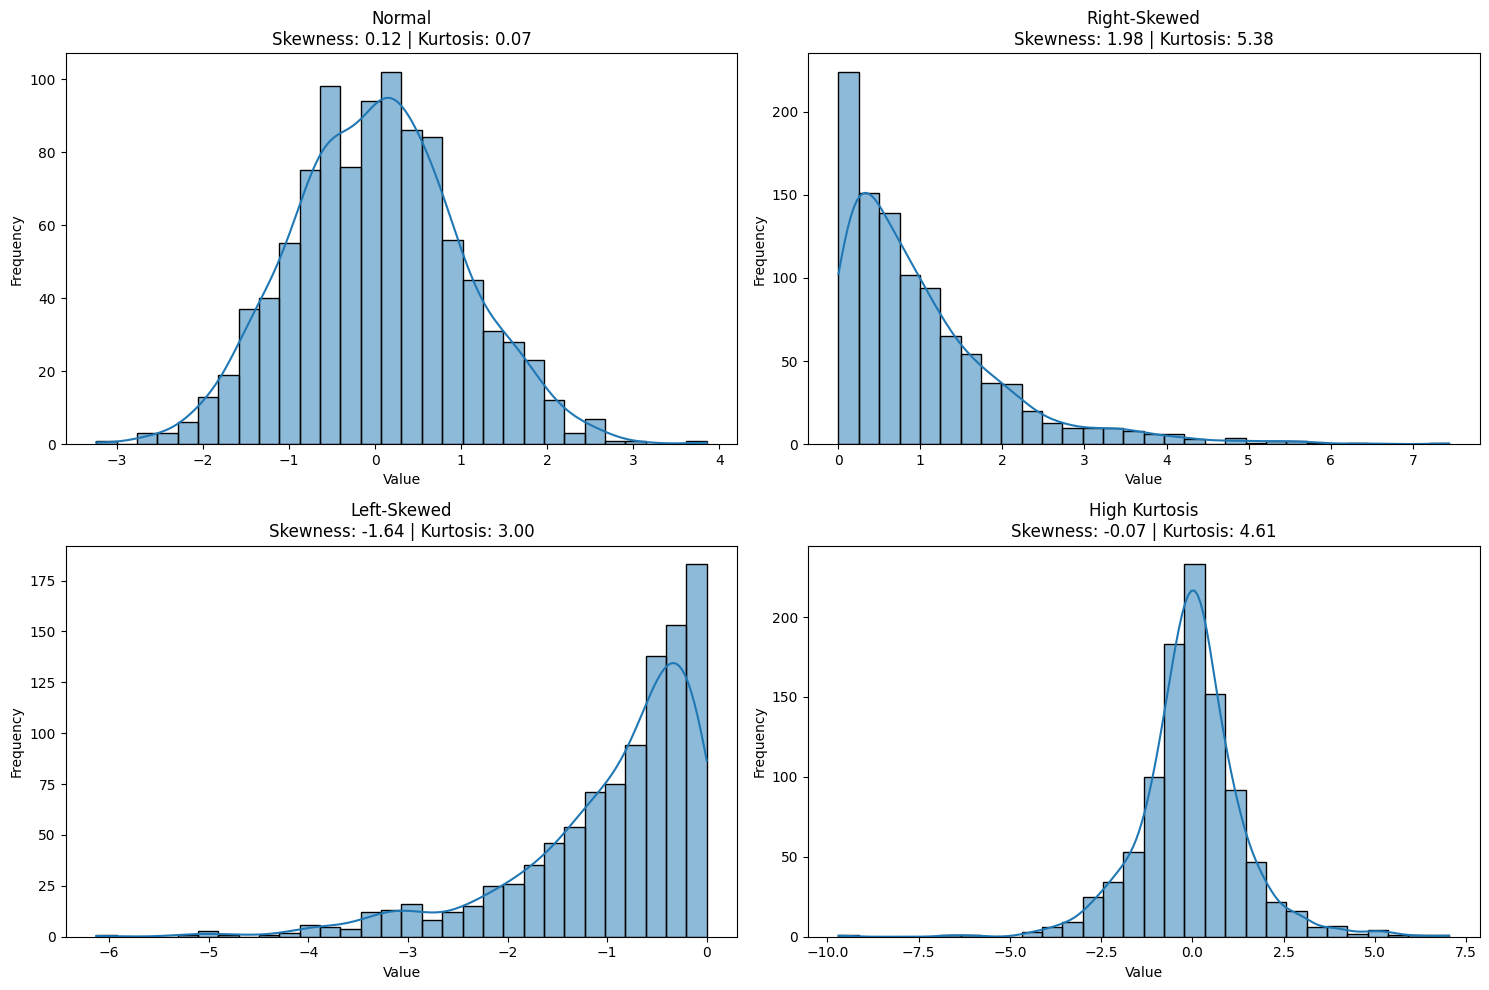


Summary Statistics:
Distribution      Skewness   Kurtosis
----------------------------------------
Normal                0.12       0.07
Right-Skewed          1.98       5.38
Left-Skewed          -1.64       3.00
High Kurtosis        -0.07       4.61


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
import seaborn as sns

# Create example data with different distributions
np.random.seed(42)
normal_data = np.random.normal(0, 1, 1000)
right_skewed = np.random.exponential(1, 1000)
left_skewed = -np.random.exponential(1, 1000)
high_kurtosis = np.random.laplace(0, 1, 1000)

# Calculate statistics for each distribution
def calculate_stats(data, name):
    return {
        'name': name,
        'skewness': skew(data),
        'kurtosis': kurtosis(data, fisher=True),  # Fisher's definition (normal=0)
        'data': data
    }

datasets = [
    calculate_stats(normal_data, "Normal"),
    calculate_stats(right_skewed, "Right-Skewed"),
    calculate_stats(left_skewed, "Left-Skewed"),
    calculate_stats(high_kurtosis, "High Kurtosis")
]

# Create figure with subplots
plt.figure(figsize=(15, 10))

# Plot histograms with skewness/kurtosis annotations
for i, stats in enumerate(datasets, 1):
    plt.subplot(2, 2, i)
    sns.histplot(stats['data'], kde=True, bins=30)

    # Add annotations
    plt.title(f"{stats['name']}\n"
              f"Skewness: {stats['skewness']:.2f} | "
              f"Kurtosis: {stats['kurtosis']:.2f}")
    plt.xlabel('Value')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Create a summary table
print("\nSummary Statistics:")
print(f"{'Distribution':<15} {'Skewness':>10} {'Kurtosis':>10}")
print("-" * 40)
for stats in datasets:
    print(f"{stats['name']:<15} {stats['skewness']:>10.2f} {stats['kurtosis']:>10.2f}")

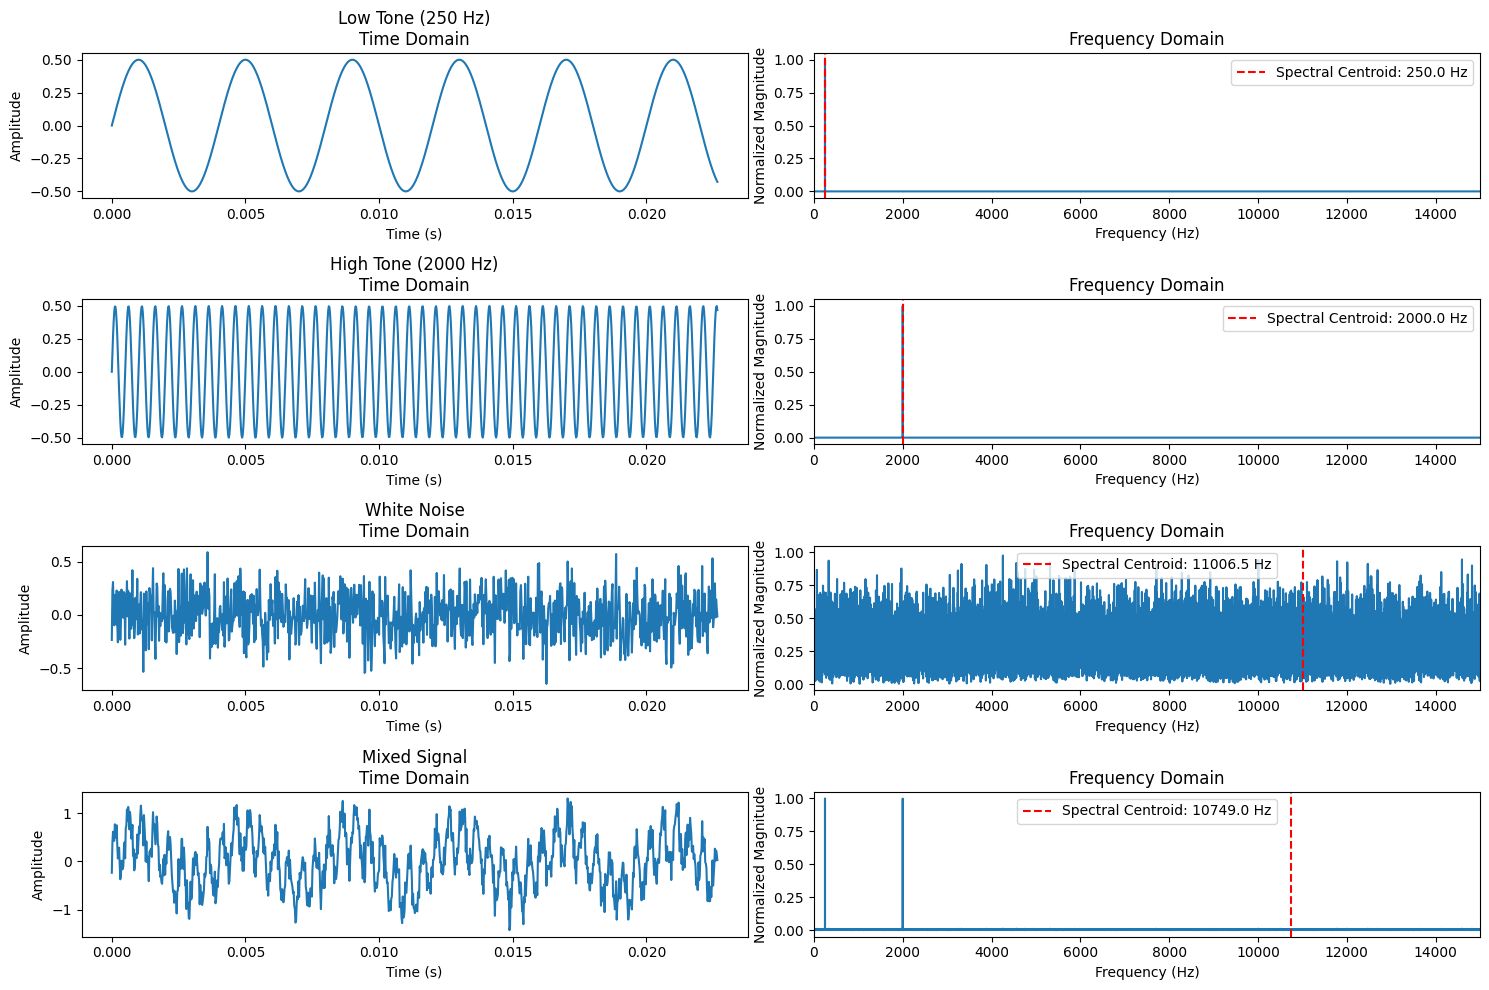

Low tone (250 Hz):
High tone (2000 Hz):
White noise:
Mixed signal:


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from IPython.display import Audio

def calculate_spectral_centroid(signal, sample_rate):
    """
    Calculate the spectral centroid of a signal.

    Args:
        signal: Input time-domain signal
        sample_rate: Sampling rate in Hz

    Returns:
        centroid: Spectral centroid in Hz
        frequencies: Array of frequencies
        magnitudes: Normalized magnitude spectrum
    """
    n = len(signal)

    # Compute FFT and take absolute value
    fft_result = fft(signal)
    magnitudes = np.abs(fft_result)[:n//2]  # Take only positive frequencies
    magnitudes = magnitudes / np.max(magnitudes)  # Normalize

    # Calculate frequencies
    frequencies = fftfreq(n, 1/sample_rate)[:n//2]

    # Calculate spectral centroid
    if np.sum(magnitudes) > 0:
        centroid = np.sum(frequencies * magnitudes) / np.sum(magnitudes)
    else:
        centroid = 0

    return centroid, frequencies, magnitudes

# Create example signals
sample_rate = 44100  # 44.1 kHz
duration = 1.0  # 1 second
t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)

# 1. Pure low-frequency tone (250 Hz)
low_tone = 0.5 * np.sin(2 * np.pi * 250 * t)

# 2. Pure high-frequency tone (2000 Hz)
high_tone = 0.5 * np.sin(2 * np.pi * 2000 * t)

# 3. White noise
noise = 0.2 * np.random.normal(0, 1, len(t))

# 4. Mixed signal (low + high + noise)
mixed_signal = low_tone + high_tone + noise

# Create figure
plt.figure(figsize=(15, 10))

# Plot each signal and its spectral centroid
signals = [
    ("Low Tone (250 Hz)", low_tone),
    ("High Tone (2000 Hz)", high_tone),
    ("White Noise", noise),
    ("Mixed Signal", mixed_signal)
]

for i, (title, signal) in enumerate(signals, 1):
    # Calculate spectral centroid
    centroid, freqs, mags = calculate_spectral_centroid(signal, sample_rate)

    # Plot time domain
    plt.subplot(4, 2, 2*i-1)
    plt.plot(t[:1000], signal[:1000])  # Show first 1000 samples
    plt.title(f"{title}\nTime Domain")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")

    # Plot frequency domain
    plt.subplot(4, 2, 2*i)
    plt.plot(freqs, mags)
    plt.axvline(centroid, color='r', linestyle='--',
                label=f'Spectral Centroid: {centroid:.1f} Hz')
    plt.title("Frequency Domain")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Normalized Magnitude")
    plt.legend()
    plt.xlim(0, 15000)  # Limit to 5kHz for visibility

plt.tight_layout()
plt.show()

# Play the sounds (if running in Jupyter notebook)
print("Low tone (250 Hz):")
Audio(low_tone, rate=sample_rate)

print("High tone (2000 Hz):")
Audio(high_tone, rate=sample_rate)

print("White noise:")
Audio(noise, rate=sample_rate)

print("Mixed signal:")
Audio(mixed_signal, rate=sample_rate)

In [ ]:
#2 Enveloping Process
time
nd_enveloped_signal = []
tr_enveloped_signal = []
fr_enveloped_signal = []

'''
for i in bandpass_signal:
  rectification_signal.append(np.abs(i))
for j in rectification_signal:
  envelope, ly = get_envelope_v1(time, j)
  enveloped_signal.append(envelope)
'''
for k in enveloped_signal:
  twoenvelope, ly = get_envelope_v1(time, k)
  nd_enveloped_signal.append(twoenvelope)
for l in nd_enveloped_signal:
  threeenvelope, ly = get_envelope_v1(time, l)
  tr_enveloped_signal.append(threeenvelope)
for m in tr_enveloped_signal:
  fourenvelope, ly = get_envelope_v1(time, m)
  fr_enveloped_signal.append(fourenvelope)

plt.figure(figsize=(10,5))
plt.plot(time, fr_enveloped_signal[59])
plt.plot(time, tr_enveloped_signal[59])
plt.plot (time, nd_enveloped_signal[59])
plt.plot (time, enveloped_signal[59])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# Fungsi Runge: contoh klasik yang menghasilkan osilasi saat diinterpolasi dengan polinomial tinggi
def runge(x):
    return 1 / (1 + 25 * x**2)

# Data titik (dengan jarak tidak seragam untuk memperburuk osilasi)
x = np.linspace(-1, 1, 11)  # 11 titik
y = runge(x)

# Interpolasi polinomial orde tinggi (contoh: orde 10)
poly_high = np.poly1d(np.polyfit(x, y, deg=10))

# Cubic spline
cs = CubicSpline(x, y, bc_type='natural')  # Natural cubic spline

# Plot
x_fine = np.linspace(-1, 1, 500)
plt.figure(figsize=(10, 6))
plt.plot(x_fine, runge(x_fine), 'k-', label="Fungsi", alpha = 0.2)
plt.plot(x, y, 'ro', label="Data Points")
plt.plot(x_fine, poly_high(x_fine), 'b--', label="Polinomial Orde 10")
plt.plot(x_fine, cs(x_fine), 'g-', label="Cubic Interpolation")
plt.ylim(-0.5, 1.5)
plt.legend()
#plt.title("Runge Phenomenon: Polinomial Tinggi vs Cubic Spline")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()